In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185, ?

<h1>CUP - SVM</h1>
<p>Exploring the cup dataset with SVM Classifier.</p>
<hr/>

In [2]:
import importlib
import warnings
import numpy as np
from scipy.linalg import LinAlgWarning
from sklearn import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.exceptions import FitFailedWarning
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_ridge import KernelRidge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import cup_common as cc
import svm_common as sc
import cross_common as cr
from cross_common import MEE,MSE,RMSE,MAE,R2


In [3]:
# Ignore warning that might occur during grid search
warnings.filterwarnings("ignore", category=UserWarning, append=True)
warnings.filterwarnings("ignore", category=LinAlgWarning,append=True)
warnings.filterwarnings("ignore", category=FitFailedWarning, append=True)

In [4]:
importlib.reload(sc)
importlib.reload(cc)
importlib.reload(cr)

<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

<h2>Preparation</h2>

<h3>Hyperparameters</h3>

In [5]:

param_grid_default = {
    "model__n_estimators": [100, 300, 500],
    "model__max_depth": [None, 10, 20, 40],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5],
    "model__bootstrap": [True]
}

# We only test SVR
pipe_default = Pipeline(steps=[
    #("scaler", StandardScaler()), <- RandomForest does not require a scaler
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

# --- The metrics to compute in training ---
metrics_dict = {
    MEE: (cr.mee, min),
    MSE: (cr.mse,min),
    MAE: (cr.mae,min),
    RMSE: (cr.rmse,min),
    R2: (cr.r2,min),
}
the_metrics = metrics_dict.keys()
# ------------------------------------------

# Common scoring
default_metric = MEE
scoring = cr.common_scoring(default_metric)

# Common CV fold strategy
outer_cv = cr.common_fold_strategy()


<h3>Data Loading</h3>

In [6]:
df_train, df_test = cc.load_set()
X_tr, y_tr = cc.prepare_dataset(df_train)
X_ts, y_ts = cc.prepare_dataset(df_test)
features_names = X_tr.columns
cr.dataset_introspection(X_tr, X_ts)

,Property,Training,Test
0,Number of samples,500,1000
1,Number of features,10,10
2,Class values,[],[]
3,Class balance,[],[]


<h3>Baseline</h3>

In [7]:
importlib.reload(cr)
model_baseline = cr.model_baseline(X_tr, y_tr, outer_cv)

----------------------------------------
Baseline: DummyRegressor()
Mean baseline: 35.79302825927734
Scorer: make_scorer(neg_mean_euclidean_error, greater_is_better=False, response_method='predict')
Raw scores: [-36.10307312 -34.5480423  -35.62013626 -35.9157486  -36.77814102]


<h3>Best Model</h3>

In [8]:
# Perform a grid search
gs = GridSearchCV(
    estimator = pipe_default,
    param_grid = param_grid_default,
    cv = outer_cv,
    scoring = scoring,
    n_jobs = -1 # use all available cores
)

# Fit TR features and labels into grid
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    gs.fit(X_tr, y_tr)

In [9]:
best_estimator = gs.best_estimator_
best_model, best_params = cr.extract_best_pipeline_metrics_from_grid(gs)
cr.grid_introspection(gs)

Grid summary
----------------------------------------
Total model explored: 324  splits: 5
Best params: {'model__bootstrap': True, 'model__max_depth': None, 'model__max_features': 0.5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 500}
Best score: -20.794660347435048
Best model: Pipeline(steps=[('model',
                 RandomForestRegressor(max_features=0.5, n_estimators=500,
                                       n_jobs=-1, random_state=42))])


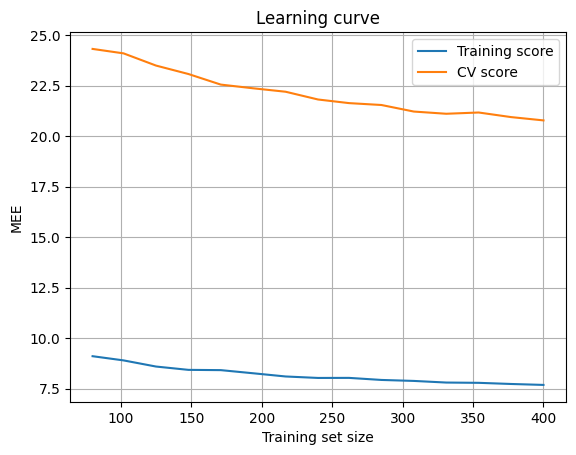

In [10]:
importlib.reload(cr)
cr.plot_learning_curve(best_model, X_tr, y_tr, outer_cv, scoring=scoring)

<h2>Model estimation</h2>
<p>The model is estimated trough two different approaches: non nested and nested KFold.</p>
<hr/>

<h3>Non nested Cross Validation</h3>

In [11]:
importlib.reload(cr)

non_nested_runner = cr.SklearnRegressorRunner(clone(gs.best_estimator_).set_params(**gs.best_params_))
kf_result = cr.kfold(non_nested_runner, X_tr, y_tr, outer_cv, metrics=metrics_dict)

  
Perform fold: 1, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation mee       | 20.5477
Validation mse       | 133.7781
Validation mae       | 9.3915
Validation rmse      | 11.5662
Validation r2        | 0.5634
Train                | samples: 400
Validation           | samples: 100
  
Perform fold: 2, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation mee       | 20.8209
Validation mse       | 143.0613
Validation mae       | 9.4784
Validation rmse      | 11.9608
Validation r2        | 0.5169
Train                | samples: 400
Validation           | samples: 100
  
Perform fold: 3, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation mee       | 20.1367
Validation mse       | 127.6272
Validation mae       | 9.1990
Validation rms

In [12]:
best_idx = gs.best_index_
mean_score = gs.cv_results_["mean_test_score"][best_idx]
std_score  = gs.cv_results_["std_test_score"][best_idx]
print(f"Best CV grid score: {mean_score:.4f} ± {std_score:.4f}")
mean, std = cr.extract_mean_std(kf_result, f"fold_vl_{default_metric}")
print(f"Best CV func score: {mean:.4f} ± {std:.4f}")

Best CV grid score: -20.7947 ± 0.5260
Best CV func score: 20.7947 ± 0.5260


<h3>Nested Cross Validation</h3>

In [14]:
importlib.reload(cr)

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

inner_cv = cr.common_fold_strategy(n_split=3)
outer_cv = outer_cv

gs_inner = GridSearchCV(
    pipe_default,
    param_grid=param_grid_default,
    scoring=scoring,
    cv=inner_cv,
    n_jobs=-1,
    return_train_score=True
)
nested_runner = cr.SklearnNestedRegressorRunner(gs_inner)
with warnings.catch_warnings():
    nested_result = cr.kfold(nested_runner, X_tr, y_tr, outer_cv, metrics=metrics_dict)

  
Perform fold: 1, train size: 400, val size: 100
Grid summary
----------------------------------------
Total model explored: 324  splits: 3
Best params: {'model__bootstrap': True, 'model__max_depth': 10, 'model__max_features': 0.5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best score: -21.597145663890544
Best model: Pipeline(steps=[('model',
                 RandomForestRegressor(max_depth=10, max_features=0.5,
                                       n_estimators=300, n_jobs=-1,
                                       random_state=42))])
 
Fold summary
--------------------------------------------------------------------------------
Validation mee       | 20.8718
Validation mse       | 137.6214
Validation mae       | 9.5473
Validation rmse      | 11.7312
Validation r2        | 0.5537
Train                | samples: 400
Validation           | samples: 100
  
Perform fold: 2, train size: 400, val size: 100
Grid summary
-----------------------

<p>This plot shows the evolution of training and cross-validation errors as the training set size increases. The learning curve helps assess whether the model suffers from underfitting or overfitting and whether performance is limited by model capacity or by intrinsic noise in the data.</p>

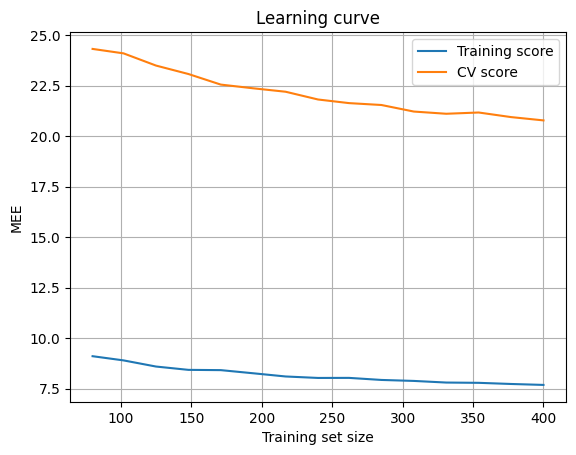

In [15]:
importlib.reload(cr)
cr.plot_learning_curve(best_estimator, X_tr, y_tr, outer_cv, scoring=gs.scoring)

<h3>Results</h3>
<hr/>

<p>We expect that non nested KFold result has more optimistic metrics in respect to nested KFold.</p>

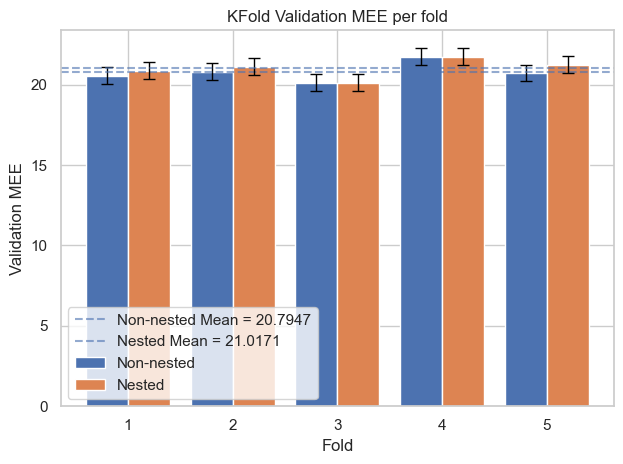

TR vs VL from KFold Nested results


,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,8.974895,20.871832,11.896937,132.56%
2,7.782761,21.132515,13.349754,171.53%
3,7.801247,20.115728,12.314481,157.85%
4,7.523180,21.735370,14.212190,188.91%
5,7.949653,21.230133,13.280480,167.06%
MEAN,8.006347,21.017116,13.010768,163.58%
STD,0.562762,0.593336,0.916038,20.69%


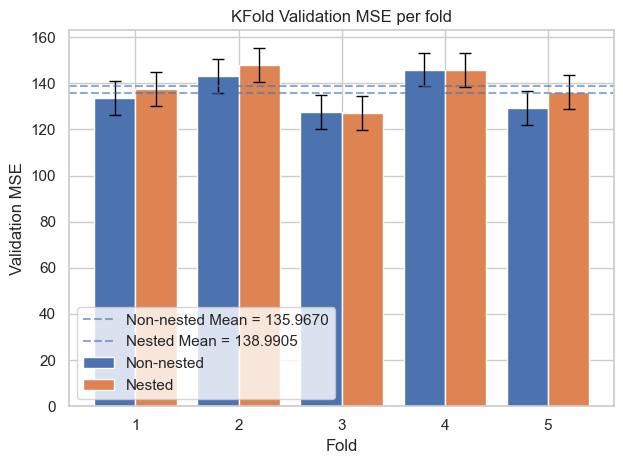

TR vs VL from KFold Nested results


,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,24.589993,137.621383,113.031390,459.66%
2,19.494858,147.790782,128.295924,658.10%
3,19.167737,127.285890,108.118154,564.06%
4,18.123900,145.945439,127.821539,705.27%
5,20.229716,136.308909,116.079193,573.81%
MEAN,20.321241,138.990480,118.669240,592.18%
STD,2.503618,8.244383,9.031289,94.64%


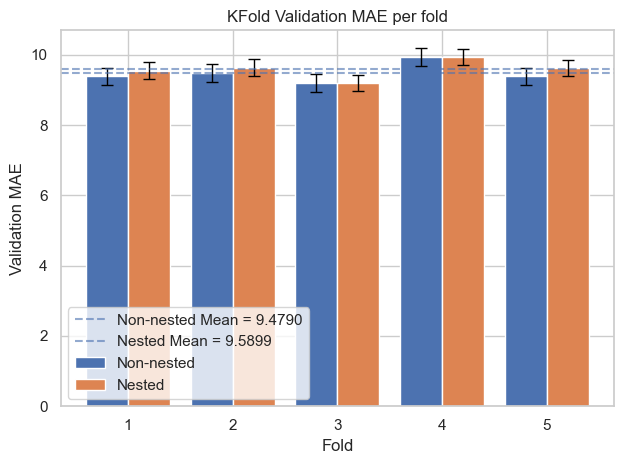

TR vs VL from KFold Nested results


,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,4.066434,9.547292,5.480857,134.78%
2,3.553817,9.637815,6.083999,171.20%
3,3.554654,9.197176,5.642521,158.74%
4,3.420304,9.938455,6.518151,190.57%
5,3.623861,9.628723,6.004862,165.70%
MEAN,3.643814,9.589892,5.946078,164.20%
STD,0.247493,0.265208,0.405685,20.26%


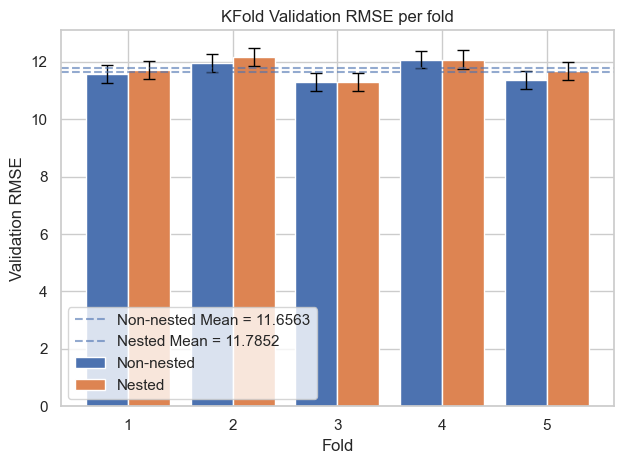

TR vs VL from KFold Nested results


,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,4.958830,11.731214,6.772384,136.57%
2,4.415298,12.156923,7.741625,175.34%
3,4.378097,11.282105,6.904007,157.69%
4,4.257217,12.080788,7.823571,183.77%
5,4.497746,11.675141,7.177395,159.58%
MEAN,4.501438,11.785234,7.283796,162.59%
STD,0.269953,0.351313,0.479079,18.17%


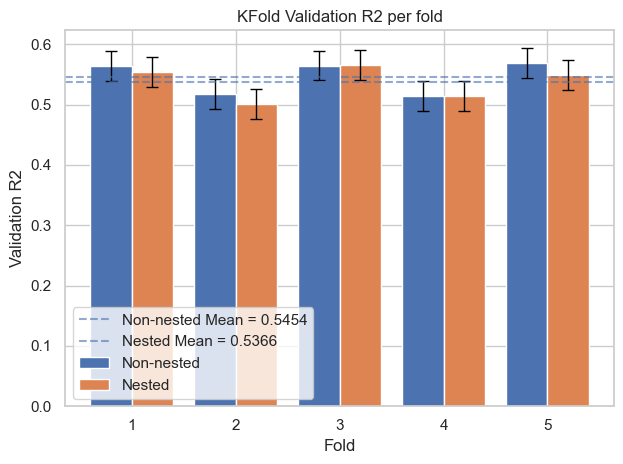

TR vs VL from KFold Nested results


,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,0.917224,0.553739,-0.363485,39.63%
2,0.935829,0.501154,-0.434674,46.45%
3,0.936958,0.565756,-0.371202,39.62%
4,0.940366,0.513805,-0.426561,45.36%
5,0.932670,0.548534,-0.384136,41.19%
MEAN,0.932610,0.536598,-0.396012,42.45%
STD,0.009030,0.027669,0.032568,3.24%


In [19]:
for metric in the_metrics:
    cr.plot_kfold_metric([(kf_result,"Non-nested"), (nested_result, "Nested")], metric)
    print("TR vs VL from KFold Nested results")
    display(cr.kfold_regression_table(nested_result, use=metric))

<h3>Bootstrap Variance</h3>

In [21]:
importlib.reload(cr)
bootstrap_samples = 50
bootstrap_rstate = 42
samples = cr.generate_bootstrap_samples_from_dataset(X_tr, y_tr, n_samples=bootstrap_samples, random_state=bootstrap_rstate)
bootstrap_params = {"silence_output": True}

with warnings.catch_warnings():
    bootstrap_scores = cr.bootstrap_out_of_bag_scores(non_nested_runner, X_tr, y_tr, samples, metrics_dict,bootstrap_params=bootstrap_params)


In [23]:
cr.aggregate_scores(bootstrap_scores)

,metric,means,stds
0,mee,21.20,0.76
1,rmse,11.93,0.44
2,mse,142.63,10.37
3,r2,0.53,0.03
4,mae,9.67,0.35


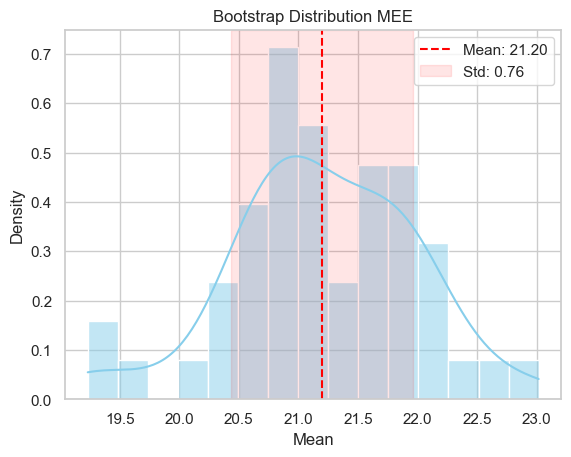

In [26]:
cr.plot_bootstrap_distribution([metric[MEE] for metric in bootstrap_scores], title="Bootstrap Distribution MEE")

<h2>Test predictions</h2>
<hr/>

In [ ]:
unfitted_model = non_nested_runner.new_model()
fitted_model = non_nested_runner.fit(unfitted_model, X_tr, y_tr)
y_pred = non_nested_runner.predict(fitted_model, X_ts)

In [ ]:
print(y_pred)

<hr/>